#Team-wise Spending Strategy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/Project_2/TATA-IPL-2025-Auction-Final-List-cleaned.xlsx')

In [ ]:
df.head()

,full name,Country,State Association,National/International,Age,Age Group,2024 Team,C/U,Team,Type,Base,Sold,Category
0,Jos Buttler,England,International,International,34,30-35,RR,Capped,GT,BAT,2,15.75,Auctioned
1,Shreyas Iyer,India,MCA,National,30,30-35,KKR,Capped,PBKS,BAT,2,26.75,Auctioned
2,Rishabh Pant,India,DDCA,National,27,25-30,DC,Capped,LSG,BAT,2,27.00,Auctioned
3,Kagiso Rabada,South Africa,International,International,29,25-30,PBKS,Capped,GT,BOWL,2,10.75,Auctioned
4,Arshdeep Singh,India,PCA,National,26,25-30,PBKS,Capped,PBKS,BOWL,2,18.00,Auctioned


##Team Spending Summary

In [ ]:
team_summary = (
    df.groupby('Team')
      .agg(
          Total_Spending=('Sold', 'sum'),
          Players_Bought=('full name', 'count'),
          Avg_Player_Price=('Sold', 'mean'),
          Median_Player_Price=('Sold', 'median')
      )
      .sort_values('Total_Spending', ascending=False)
)

team_summary

,Total_Spending,Players_Bought,Avg_Player_Price,Median_Player_Price
Team,,,,
CSK,119.95,25,4.798000,2.4
GT,119.85,25,4.794000,2.0
SRH,119.80,20,5.990000,2.8
MI,119.80,23,5.208696,1.0
RR,119.70,20,5.985000,4.1
PBKS,119.65,25,4.786000,2.0
LSG,119.60,23,5.200000,2.4
RCB,119.25,22,5.420455,2.8
DC,116.55,23,5.067391,2.2


## 1. Team Spending Summary

Most franchises utilized almost their entire ₹120 Cr auction budget, indicating a highly competitive auction with minimal unused funds. However, spending efficiency varied considerably. **SRH (₹5.99 Cr)** and **RR (₹5.99 Cr)** recorded the highest average player price despite signing only **20 players**, reflecting a premium-quality acquisition strategy. In contrast, **CSK (25 players, ₹4.80 Cr)**, **GT (25 players, ₹4.79 Cr)** and **PBKS (25 players, ₹4.79 Cr)** spread similar budgets across larger squads, suggesting greater squad depth. **MI's** median player price of just **₹1.0 Cr** highlights that a few marquee signings significantly increased its average spending.

---


##Top 5 Player Spending (Budget Concentration)
Business Question

* Is the franchise dependent on a few expensive players or spreading money across the squad?

In [ ]:
top5_spending = (
    df.sort_values(['Team', 'Sold'], ascending=[True, False])
      .groupby('Team')
      .head(5)
      .groupby('Team')
      .agg(
          Top5_Spending=('Sold', 'sum')
      )
)

top5_spending['Top5_%'] = (
    top5_spending['Top5_Spending'] /
    team_summary['Total_Spending']
) * 100

top5_spending = top5_spending.round(2)

top5_spending

,Top5_Spending,Top5_%
Team,,
CSK,71.00,59.19
DC,66.25,56.84
GT,73.25,61.12
KKR,72.75,67.39
LSG,79.75,66.68
MI,79.50,66.36
PBKS,80.75,67.49
RCB,67.00,56.18
RR,76.50,63.91


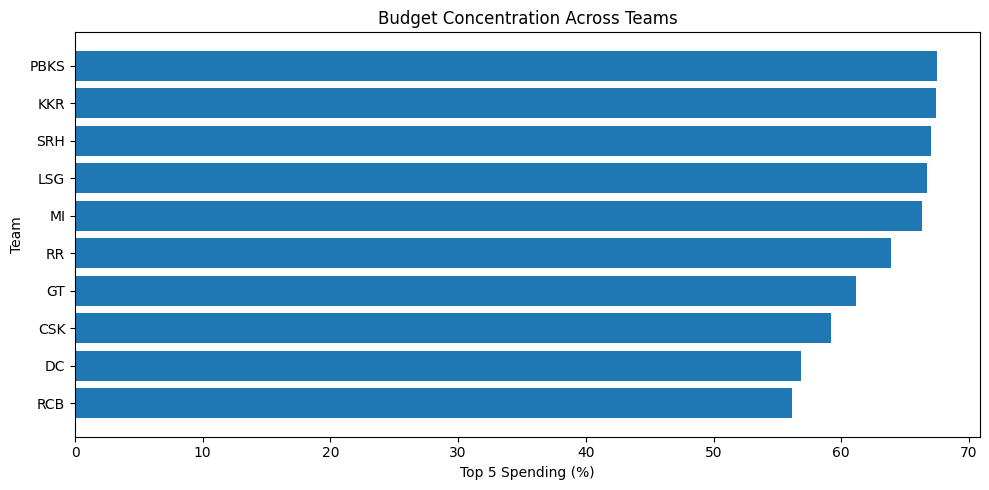

In [ ]:
import matplotlib.pyplot as plt

top5_spending = top5_spending.sort_values('Top5_%')

plt.figure(figsize=(10,5))
plt.barh(top5_spending.index, top5_spending['Top5_%'])
plt.xlabel('Top 5 Spending (%)')
plt.ylabel('Team')
plt.title('Budget Concentration Across Teams')
plt.tight_layout()
plt.show()

## 2. Budget Concentration (Top 5 Player Spending)

A substantial share of every franchise's budget was allocated to just five players, highlighting the importance of marquee signings. **PBKS (67.49%)**, **KKR (67.39%)**, **SRH (66.99%)**, **LSG (66.68%)**, and **MI (66.36%)** invested nearly two-thirds of their total budgets in their top five acquisitions, indicating a **star-focused** strategy. On the other hand, **RCB (56.18%)** and **DC (56.84%)** distributed spending more evenly across the squad, reducing dependence on a small group

---

##Investment Diversification
Business Question

* How evenly did franchises distribute their auction budget?

In [ ]:
diversification = (
    df.groupby('Team')['Sold']
      .agg(['mean', 'std'])
)

#Coefficient of Variation CV
diversification['CV'] = (
    diversification['std'] /
    diversification['mean']
)

diversification = diversification[['CV']].round(2)

diversification

,CV
Team,
CSK,1.14
DC,1.06
GT,1.18
KKR,1.18
LSG,1.35
MI,1.22
PBKS,1.41
RCB,1.02
RR,1.04


## 3. Investment Diversification

The Coefficient of Variation (CV) shows how evenly teams distributed player investments. **PBKS (CV = 1.41)** and **LSG (CV = 1.35)** had the highest variability, indicating aggressive spending on a few premium players while keeping the remaining squad relatively inexpensive. Conversely, **RCB (CV = 1.02)**, **RR (1.04)** and **DC (1.06)** displayed the most balanced investment patterns, suggesting lower financial concentration risk and a more diversified squad-building approach.

---



##Squad Balance (Role Investment)

Business Question

* Which skill areas received the highest investment?

In [ ]:
role_spending = (
    df.pivot_table(
        values='Sold',
        index='Team',
        columns='Type',
        aggfunc='sum',
        fill_value=0
    )
)

role_spending

Type,AR,BAT,BOWL
Team,,,
CSK,54.55,32.80,32.60
DC,23.35,46.50,46.70
GT,26.50,37.80,55.55
KKR,54.15,25.65,28.15
LSG,14.60,58.85,46.15
MI,37.45,34.90,47.45
PBKS,37.55,39.10,43.00
RCB,22.40,56.80,40.05
RR,36.55,45.20,37.95


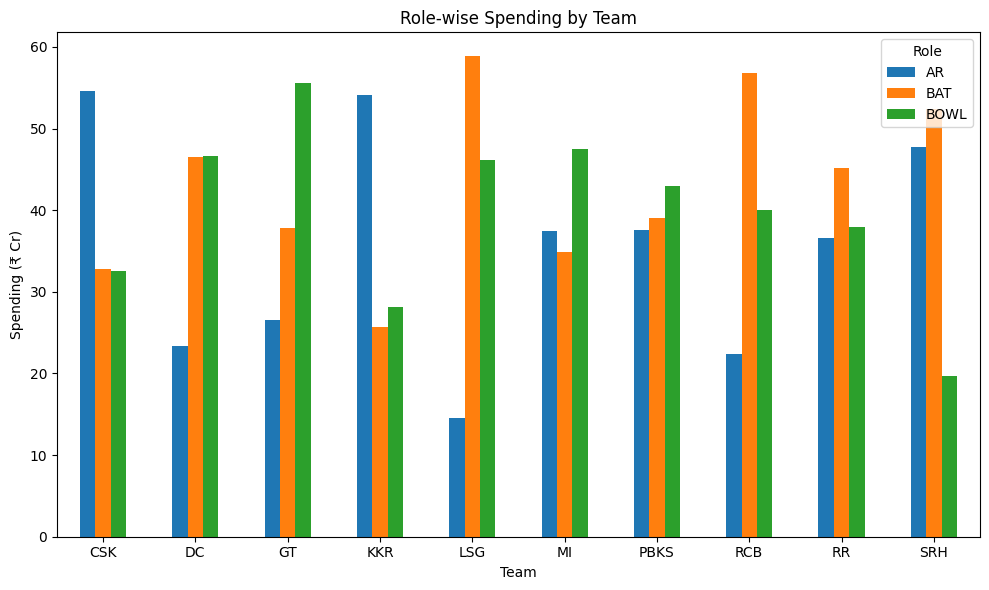

In [ ]:
role_spending.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Role-wise Spending by Team')
plt.xlabel('Team')
plt.ylabel('Spending (₹ Cr)')
plt.xticks(rotation=0)
plt.legend(title='Role')
plt.tight_layout()
plt.show()

## 4. Role Investment Strategy

Franchises clearly prioritized different skill sets based on their team-building philosophy. **CSK (₹54.55 Cr)** and **KKR (₹54.15 Cr)** invested most heavily in all-rounders, emphasizing squad flexibility. **LSG (₹58.85 Cr)** and **RCB (₹56.80 Cr)** focused primarily on specialist batters, while **GT (₹55.55 Cr)** and **MI (₹47.45 Cr)** allocated the largest share of their budgets to bowlers, strengthening their bowling attack. **SRH** adopted a batting and all-rounder-focused strategy, spending **₹52.35 Cr** on batters and **₹47.75 Cr** on all-rounders while investing only **₹19.70 Cr** in bowlers.

---



##Domestic vs Overseas Mix

Business Question

* Which teams relied more on overseas talent?

In [ ]:
overseas_mix = (
    df.groupby(['Team', 'National/International'])
      .agg(
          Players=('full name', 'count'),
          Spending=('Sold', 'sum')
      )
      .reset_index()
)

overseas_mix

,Team,National/International,Players,Spending
0,CSK,International,7,39.15
1,CSK,National,18,80.80
2,DC,International,7,40.50
3,DC,National,16,76.05
4,GT,International,7,52.25
5,GT,National,18,67.60
6,KKR,International,8,42.40
7,KKR,National,13,65.55
8,LSG,International,6,35.40
9,LSG,National,17,84.20


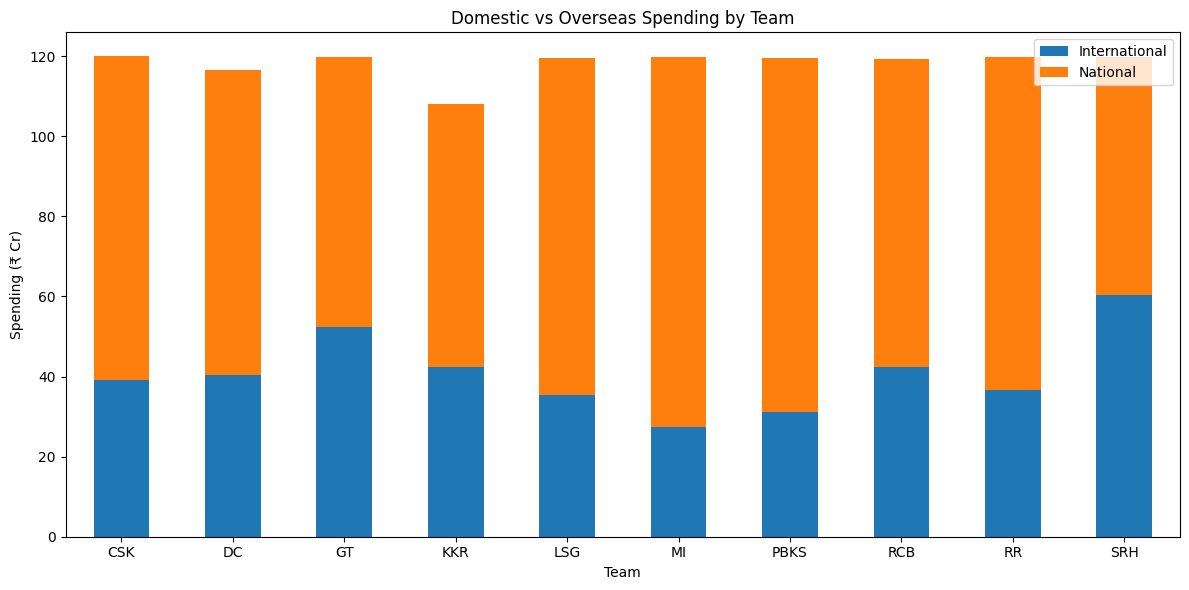

In [ ]:
dom_over = overseas_mix.pivot(
    index='Team',
    columns='National/International',
    values='Spending'
)

dom_over.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Domestic vs Overseas Spending by Team')
plt.xlabel('Team')
plt.ylabel('Spending (₹ Cr)')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()

## 5. Domestic vs Overseas Mix

Most franchises relied primarily on domestic talent for both squad size and spending. **SRH** was the only team with an almost equal financial split between domestic (**₹59.45 Cr**) and overseas (**₹60.35 Cr**) players, indicating the strongest reliance on international talent. **GT** also made significant overseas investments (**₹52.25 Cr**), whereas **MI (₹27.35 Cr)** and **PBKS (₹31.25 Cr)** allocated the smallest budgets to overseas players, reflecting a domestic-heavy recruitment strategy.

---



##Capped vs Uncapped Mix

Business Question

* Which teams invested in proven international players versus emerging domestic talent?

In [ ]:
capped_mix = (
    df.groupby(['Team', 'C/U'])
      .agg(
          Players=('full name', 'count'),
          Spending=('Sold', 'sum')
      )
      .reset_index()
)

capped_mix

,Team,C/U,Players,Spending
0,CSK,Capped,15,110.80
1,CSK,Uncapped,10,9.15
2,DC,Capped,12,103.00
3,DC,Uncapped,11,13.55
4,GT,Capped,14,103.70
5,GT,Uncapped,11,16.15
6,KKR,Capped,15,98.15
7,KKR,Uncapped,6,9.80
8,LSG,Capped,11,102.15
9,LSG,Uncapped,12,17.45


## 6. Capped vs Uncapped Mix

Every franchise prioritized experienced players, with over **80%** of total spending directed toward capped cricketers. **SRH (₹112.60 Cr)**, **MI (₹111.60 Cr)** and **RR (₹111.35 Cr)** invested almost their entire budgets in proven players, indicating a win-now approach. **PBKS** stood out by investing **₹24.85 Cr** in uncapped players—the highest among all teams—suggesting a stronger emphasis on emerging talent and future potential than its competitors.


---


# Overall Team Strategy Classification

| Team     | Strategy                     | Evidence                                                                                                                            |
| -------- | ---------------------------- | ----------------------------------------------------------------------------------------------------------------------------------- |
| **CSK**  | Balanced                     | Large squad (25 players), moderate average price, high all-rounder investment, moderate budget concentration (59.2%).               |
| **DC**   | Balanced / Value-based       | Lowest budget concentration (56.8%), low CV (1.06), balanced spending across batting and bowling.                                   |
| **GT**   | Overseas-leaning             | Highest overseas spending after SRH (₹52.25 Cr), major investment in bowlers, moderate concentration.                               |
| **KKR**  | Star-focused                 | 67.4% of budget spent on top five players with heavy all-rounder investment.                                                        |
| **LSG**  | Star-focused                 | High budget concentration (66.7%), second-highest CV (1.35), batting-centric investment.                                            |
| **MI**   | Domestic-heavy               | Lowest overseas spending (₹27.35 Cr), significant investment in capped domestic players despite high concentration.                 |
| **PBKS** | Youth-focused + Star-focused | Highest CV (1.41), highest top-five concentration (67.5%), and largest uncapped investment (₹24.85 Cr).                             |
| **RCB**  | Balanced                     | Lowest CV (1.02), lowest top-five concentration (56.2%), strong batting investment spread across the squad.                         |
| **RR**   | Balanced                     | Low CV (1.04), premium average player price, balanced spending across all three roles.                                              |
| **SRH**  | Overseas-heavy               | Highest overseas spending (₹60.35 Cr), highest average player price (₹5.99 Cr), and premium investment in batting and all-rounders. |

---

# Executive Insight

Although almost every franchise exhausted its auction budget, their spending strategies differed significantly. **PBKS, KKR, LSG and MI** concentrated nearly **two-thirds of their budgets on five marquee players**, increasing dependence on a small core. In contrast, **RCB, DC and RR** followed more diversified investment models with the lowest spending variability, reducing financial concentration risk. Role-based spending revealed distinct priorities—**CSK and KKR** emphasized all-rounders, **GT and MI** strengthened bowling, while **LSG and RCB** built batting-heavy squads. Talent acquisition strategies also varied, with **SRH** investing the most in overseas players, **MI** and **PBKS** relying heavily on domestic talent, and **PBKS** allocating the highest budget to uncapped players. Overall, the auction reflected multiple roster-building philosophies rather than a single spending pattern, with franchises balancing immediate performance, squad depth, and long-term potential in different ways.
